In [44]:
from EXPERIMENT_HYPER_EMPIRICAL import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from matplotlib.cm import ScalarMappable
import matplotlib.colors as colors
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from scipy.sparse import diags, csc_matrix
import hypergraphx as hgx
from _HyperCommunityDetection import *
from hypergraphx.viz import draw_communities
from hypergraphx.viz.draw_hypergraph import draw_hypergraph
import warnings
import pandas
from matplotlib.ticker import MaxNLocator
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# High&Primary CM

In [18]:
name = 'highschool'
ehg = EmpiricalHyperGraph(name)
givenNumGroup = 9
only_assortative = True
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
with open(partition_path, 'rb') as fr:
    high_partition = pickle.load(fr)

high_meta = []
with open('./net_data/contact-high-school/highschool_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        high_meta.append(_data['meta'][i])
high_meta = np.array(high_meta)

Construct highschool hypergraph with 327 nodes, 7818 hyperedges and all possible k is [3, 4, 2, 5].


In [4]:
name = "primary"
ehg = EmpiricalHyperGraph(name)
edge_order, edge_count = np.unique(ehg.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
# partition detected by BH
givenNumGroup = 10
only_assortative = False
partition_path = f'./result/hyperEmpirical/{name}_BHPartition' \
                f'{f"_given{givenNumGroup}Groups" if givenNumGroup is not None else ""}' \
                f'{f"_assort" if only_assortative else ""}.pkl'
with open(partition_path, 'rb') as fr:
    primary_partition = pickle.load(fr)
# metadata (class)
primary_meta = []
with open('./net_data/contact-primary-school/primary_data.pkl', 'rb') as fr:
    _data = pickle.load(fr)
    for i in range(_data['n']):
        primary_meta.append(_data['meta'][i])
primary_meta = np.array(primary_meta)

Construct primary hypergraph with 242 nodes, 12704 hyperedges and all possible k is [2, 3, 4, 5].
{2: 7748, 3: 4600, 4: 347, 5: 9}


In [26]:
def visualMetaCM(partition, meta):
    partition_num = np.size(np.unique(partition))
    meta_num = np.size(np.unique(meta))
    cm = np.zeros((meta_num, partition_num))
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta)
    for iP in uniquePartition:
        trueIndex = np.where(partition == iP)[0]
        for iM in uniqueMeta:
            i = np.where(uniquePartition == iP)
            j = np.where(uniqueMeta == iM)
            cm[j, i] = np.size(np.where(meta[trueIndex]==iM))
    df = pandas.DataFrame(cm, uniqueMeta, uniquePartition)
    return cm, df

In [23]:
def reorder_partition(partition, meta, uniqueMeta=None):
    cm, cm_df = visualMetaCM(partition, meta)
    uniquePartition = np.unique(partition)
    uniqueMeta = np.unique(meta) if uniqueMeta is None else uniqueMeta
    partition_score = np.zeros(np.size(uniquePartition))
    for i in range(np.size(uniquePartition)):
        morelikely_j = np.argmax(cm[:, i])
        partition_score[i] = morelikely_j
        # for j in range(np.size(uniqueMeta)):
        #     partition_score[i] += (j+1) * cm[j, i]
    sort_index = np.argsort(partition_score)
    partition_map = dict()
    for i in range(np.size(sort_index)):
        partition_map[sort_index[i]] = i
    reorder_partition = np.zeros(np.size(partition))
    for i in range(np.size(partition)):
        reorder_partition[i] = partition_map[partition[i]]
    return reorder_partition, partition_score[sort_index]

[[33.  0.  0.  0.  0.  3.  0.  0.  0.]
 [ 0. 25.  0.  0.  0.  9.  0.  0.  0.]
 [ 0.  1. 19. 14.  0.  6.  0.  0.  0.]
 [ 0.  0.  0.  0. 28.  5.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 28.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 37.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 12. 32.  0.  0.]
 [ 0.  0.  0.  0.  0. 10.  0. 29.  0.]
 [ 0.  0.  0.  0.  0.  8.  0.  0. 26.]]
[0 1 2 3 4 5 6 7 8]
[[23.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 25.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. 23.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 26.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 23.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. 21.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. 21.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1. 22.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. 21.  1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0. 24.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]]


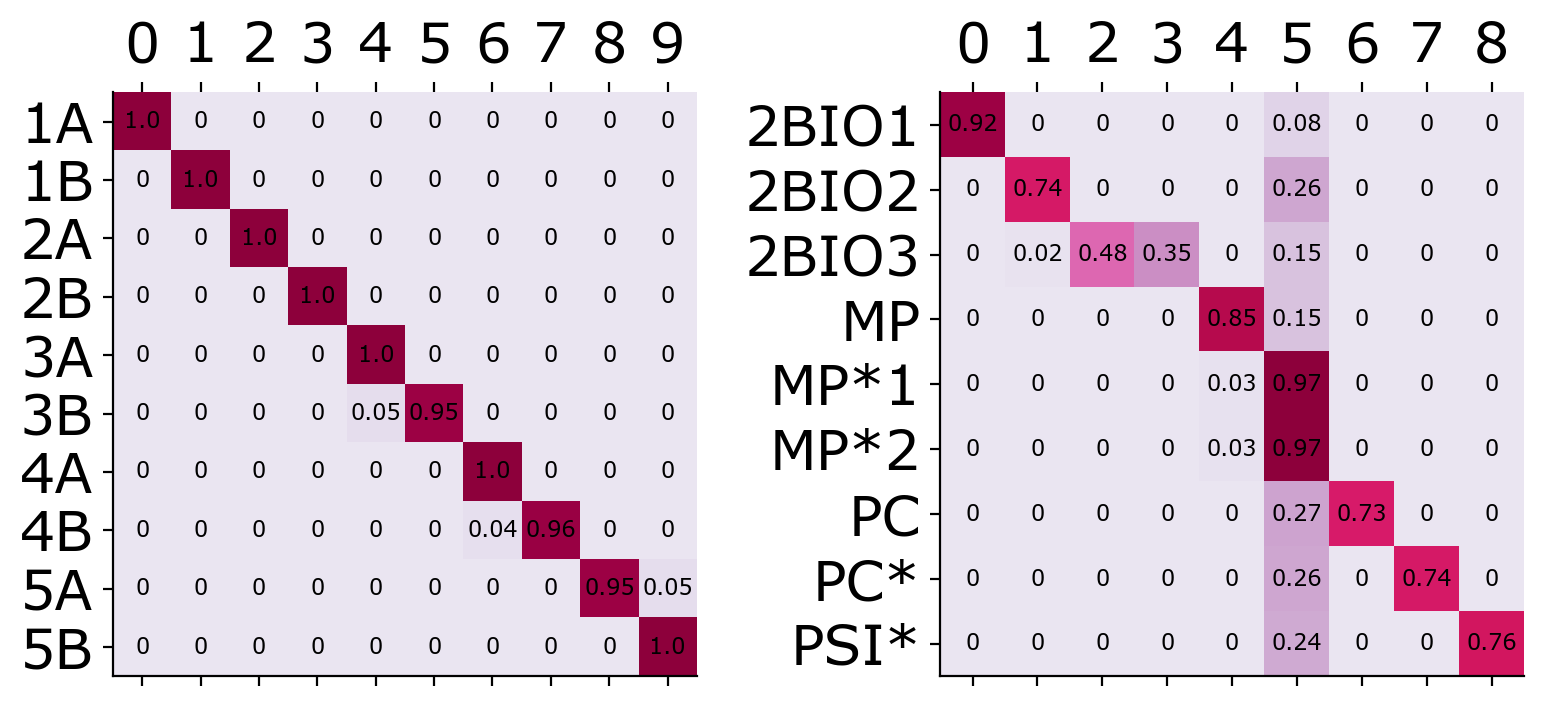

In [37]:
fig = plt.figure(figsize=(8, 4))
widths = [4, 4]
heights = [4]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
# Metadata incidence matrix
meta_labels = ['2BIO1', '2BIO2', '2BIO3', 'MP', 'MP*1', 'MP*2', 'PC', 'PC*', 'PSI*']
# reorder partition incidence matrix
reordered_partition, _ = reorder_partition(high_partition, high_meta, uniqueMeta=meta_labels)
cm, df = visualMetaCM(reordered_partition, high_meta)
# cmap = mpl.colormaps["seismic_r"]
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.1, 0.9)
rowsum = np.sum(cm, axis=1)
rowsum = rowsum.reshape(-1, 1)
rowsum = np.repeat(rowsum, np.shape(cm)[1], axis=1)
norm_cm = np.round(cm / rowsum, 2)
print(cm)
ax.matshow(norm_cm, cmap=cmap, vmin=0, vmax=np.max(norm_cm))
for i in range(np.shape(cm)[0]):
    for j in range(np.shape(cm)[1]):
        c = norm_cm[i,j]
        ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=8)
ax.set_xticks(np.arange(0, np.shape(cm)[1]), np.arange(0, np.shape(cm)[1]), fontsize=20)
ax.set_yticks(np.arange(0, np.shape(cm)[0]), meta_labels, fontsize=20)
print(ax.get_xticks())

row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
# Metadata incidence matrix
meta_labels = ['1A', '1B', '2A', '2B', '3A', '3B', '4A', '4B', '5A', '5B', 'Teachers']
# reorder partition incidence matrix
reordered_partition, _ = reorder_partition(primary_partition, primary_meta, uniqueMeta=meta_labels)
cm, df = visualMetaCM(reordered_partition, primary_meta)
# cmap = mpl.colormaps["seismic_r"]
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.1, 0.9)
rowsum = np.sum(cm, axis=1)
rowsum = rowsum.reshape(-1, 1)
rowsum = np.repeat(rowsum, np.shape(cm)[1], axis=1)
norm_cm = np.round(cm / rowsum, 2)
norm_cm = np.delete(norm_cm, -1, axis=0)
print(cm)
ax.matshow(norm_cm, cmap=cmap, vmin=0, vmax=np.max(norm_cm))
for i in range(np.shape(norm_cm)[0]):
    for j in range(np.shape(norm_cm)[1]):
        c = norm_cm[i,j]
        ax.text(j, i, str(np.round(c, 3) if c != 0 else 0), va='center', ha='center', fontsize=8)
ax.set_xticks(np.arange(0, np.shape(norm_cm)[1]), np.arange(0, np.shape(norm_cm)[1]), fontsize=20)
ax.set_yticks(np.arange(0, np.shape(norm_cm)[0]), np.array(meta_labels)[:-1], fontsize=20)
save_path = "./_Figure/Hyper/" + "FigureHighPrimaryCm.pdf"
plt.tight_layout()
plt.savefig(save_path, dpi=600)

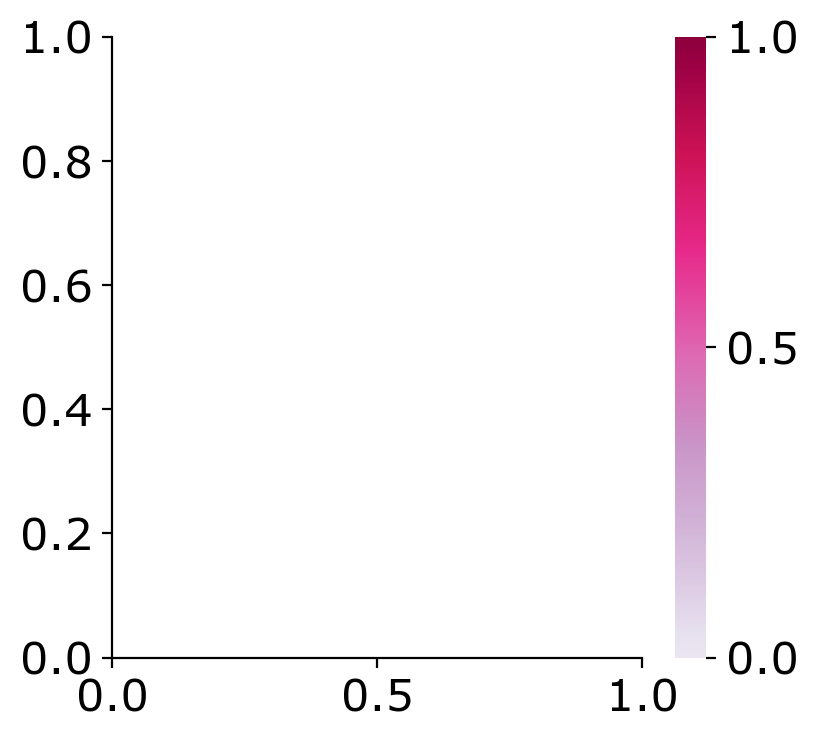

In [50]:
fig = plt.figure(figsize=(8, 4))
widths = [4, 4]
heights = [4]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["PuRd"]
cmap = truncate_colormap(cmap, 0.1, 0.9)
n_bin= 1
# ticks = n_bin * ((1/(2*(n_bin))) + np.arange(n_bin) * (1/(n_bin)))
# print(ticks)
ticks = [0, 0.5, 1]
cbar = plt.colorbar(ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_bin)), ticks=ticks, label='', ax=ax)
cbar.outline.set_visible(False)
save_path = f"./_Figure/Hyper/" + f"FigureHighPrimaryCMColorbar.pdf"
plt.tight_layout()
# plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=None)
plt.savefig(save_path, dpi=600, bbox_inches='tight')

# High HyperedgesSplittingPattern